<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/>

# From EDA To Preprocessing
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

## Workshop Introduction

This workbook bridges exploratory data analysis and machine learning by introducing somes of the intial steps taken to preprocess data so that it be used for modelling.

### Learning Objectives

* Understand the reasoning behind creating train-test splits
* Understand the concept of data leakage and identify some scenarios on how it can occur.
* Understand when to apply categorical encoding techniques (ordinal, one-hot) appropriate to feature semantics


### What You Will Learn

* **Data Splitting:** How and why we divide our dataset into feature target then train/test set for an ML prediction task.
* **Feature Inspection:** How to detect constant features, derivative relationships, and multicollinearity using correlation analysis
* **Categorical Encoding:** When to use ordinal encoding (ranked categories) versus one-hot encoding

### Process: How will I learn this content?

##### Outline

- Coding demos
- Group discussions
- Quiz

### Stretch Materials

* **Use transformations** (log, binning) to normalise skewed distributions and reduce outlier influence
* **Standardise features** to ensure fair model performance across all scales




# Machine Learning Preprocessing The Bridge Between EDA and Modelling

This notebook will work us through a short tour the additional steps that a Data Scientist to the preprare the data for modelling. As you we will see some the steps are driven by some of the plots we used earlier but, instead they now support a new chain of decisions.





##  Step 1: Data Creation & Problem Definition
Before we clean data, we have to understand it. We are looking at a **Loan Approval** scenario.
* **Target ($y$):** `Approved` (1 for Yes, 0 for No).
* **Features ($X$):** Income, Credit, and Property type.




# Loans Approval Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer




np.random.seed(42)
n_samples = 100
income = np.random.lognormal(mean=8.5, sigma=0.7, size=n_samples).astype(int)
properties = np.random.choice(['Urban', 'Rural', 'Suburb'], size=n_samples)
credits = np.random.choice(['Poor', 'Fair', 'Good'], size=n_samples, p=[0.2, 0.3, 0.5])
loan_policy = ['POL_2024'] * n_samples
tax_paid = income * 0.15
approved = ((income > 6000) | (np.array(credits) == 'Good')).astype(int)
reliability_score = np.random.normal(loc=0.5, scale=0.1, size=n_samples)
reliability_score = np.clip(reliability_score, 0, 1) # Ensure strictly 0-1

df = pd.DataFrame({
    'Income': income,
    'Tax_Paid': tax_paid,
    'Reliability_Score': reliability_score, # The new contrast feature
    'Loan_Policy': loan_policy,
    'Property': properties,
    'Credit': credits,
    'Approved': approved
})


In [2]:
df.head()

,Income,Tax_Paid,Reliability_Score,Loan_Policy,Property,Credit,Approved
0,6958,1043.70,0.489281,POL_2024,Urban,Fair,1
1,4461,669.15,0.451378,POL_2024,Rural,Good,1
2,7734,1160.10,0.659298,POL_2024,Urban,Good,1
3,14272,2140.80,0.456606,POL_2024,Urban,Fair,1
4,4171,625.65,0.426731,POL_2024,Suburb,Fair,0




# The Split

We split our data **immediately**. We want to keep 20% of our data*



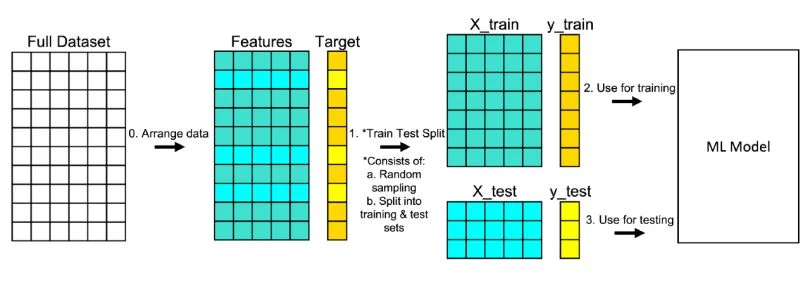

Now we implement the above using Sklearn's train_test_split module

In [3]:
df.head(3)

,Income,Tax_Paid,Reliability_Score,Loan_Policy,Property,Credit,Approved
0,6958,1043.70,0.489281,POL_2024,Urban,Fair,1
1,4461,669.15,0.451378,POL_2024,Rural,Good,1
2,7734,1160.10,0.659298,POL_2024,Urban,Good,1


In [12]:
# keep all columns except the target! this will for our features often denoted X
X = df.drop('Approved', axis=1)

# keep only the target this will form of Target often denoted as y
y = df['Approved']
# now we split a 80/20 split repsectively so we now have to form X_train,X_test and y_train,y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

let us verify that the splits are as expected

In [13]:
# check x_train
X_train.head()

,Income,Tax_Paid,Reliability_Score,Loan_Policy,Property,Credit
43,3980,597.00,0.606064,POL_2024,Rural,Good
50,6166,924.90,0.623021,POL_2024,Urban,Fair
95,1764,264.60,0.508273,POL_2024,Suburb,Poor
27,6393,958.95,0.513920,POL_2024,Suburb,Good
40,8241,1236.15,0.544629,POL_2024,Suburb,Fair


In [14]:
# check X_train.shape
X_train.shape

(80, 6)

In [17]:
# check y_train
y_train.head()

43    1
50    1
95    0
27    1
40    1
Name: Approved, dtype: int64

In [18]:
# check y_train shape
y_train.shape

(80,)

In [19]:
# check X_test
X_test.head()

,Income,Tax_Paid,Reliability_Score,Loan_Policy,Property,Credit
84,2790,418.50,0.479980,POL_2024,Urban,Good
81,6310,946.50,0.415726,POL_2024,Rural,Poor
71,14423,2163.45,0.522898,POL_2024,Rural,Poor
67,9921,1488.15,0.552796,POL_2024,Urban,Good
94,3735,560.25,0.509007,POL_2024,Urban,Good


In [20]:
# check X_test shape
X_test.shape

(20, 6)

In [21]:
#check y_test
y_test.head()

84    1
81    1
71    1
67    1
94    1
Name: Approved, dtype: int64

In [22]:
# check y_test shape
y_test.shape

(20,)

# Why Stratify?

train_test_split by default will randomly select rows from the dataframe - as a consequences there is a chance the target labels may be disproportionately present in either the training or test set not capturing the appropriate partition.

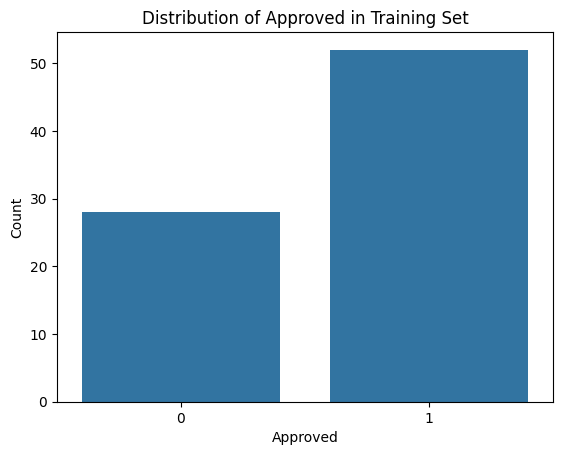

In [23]:
# show the distribution of the target variable in the training set with hue of the bars representing the count of each class
sns.countplot(x=y_train)
plt.title('Distribution of Approved in Training Set')
plt.xlabel('Approved')
plt.ylabel('Count')
plt.show()

In [24]:
# confirm the rationo of the target variable
print(y_train.value_counts(normalize=True))

Approved
1    0.65
0    0.35
Name: proportion, dtype: float64


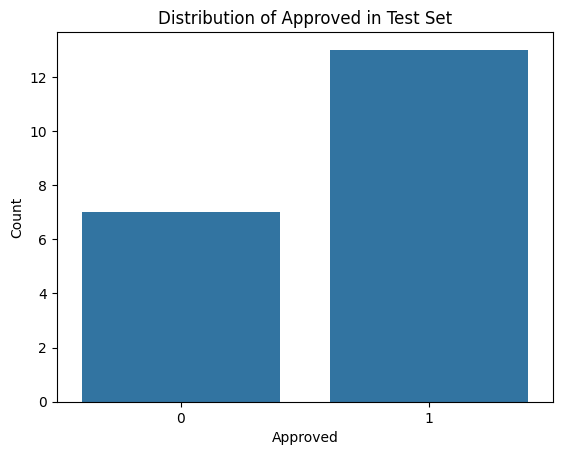

In [25]:
#show the distribution of the target variable in the test set
sns.countplot(x=y_test)
plt.title('Distribution of Approved in Test Set')
plt.xlabel('Approved')
plt.ylabel('Count')
plt.show()

In [26]:
# confirm the ratio of the target variable
print(y_test.value_counts(normalize=True))


Approved
1    0.65
0    0.35
Name: proportion, dtype: float64


# What's with the random state?

if we call train test split without a random state it will retrieve a new set of rows for the X_train,X_test,y_train,y_test this is problematic because it is hard to tell where our model improvements to predictions can be attribute to our modelling effort of that we luckily got a 'good' slice of data

---

# Group Discussion 1

---



#  Removing Redundant & Unhelpful Features

In this step, we look for "Dead Weight" — features that do not enhance the model’s predictive power.



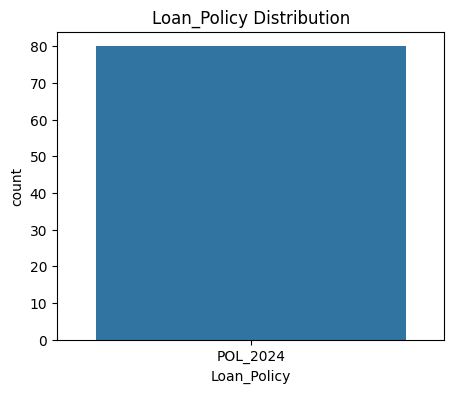

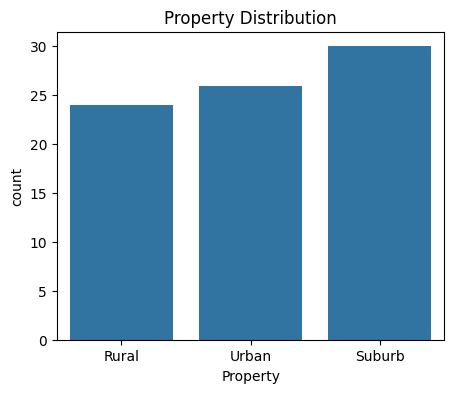

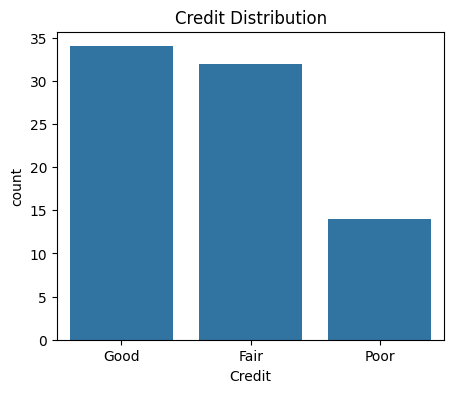

In [27]:
# plot counts plots of the catrgorical features in the training set with hue of the bars representing the count of each class
cat_cols = ['Loan_Policy', 'Property', 'Credit']

for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=col, data=X_train)
    plt.title(f"{col} Distribution")
    plt.show()

* **Constant Features:** If a column never changes (like `Loan_Policy`), it provides no information. From the describe method we can Identify that Loan Policy occurs 80 times with a single value providing no explanatory power/signal at all

In [28]:
# when one column derived exactly from another the result is 1
X_train = X_train.drop(columns=['Loan_Policy'])
X_test = X_test.drop(columns=['Loan_Policy'])

In [30]:
X_train.head(3)

,Income,Tax_Paid,Reliability_Score,Property,Credit
43,3980,597.0,0.606064,Rural,Good
50,6166,924.9,0.623021,Urban,Fair
95,1764,264.6,0.508273,Suburb,Poor


# Now we focus our attention to indentifying redundancy within our numerical features

In [31]:
X_train[['Income','Tax_Paid','Reliability_Score']].corr()

,Income,Tax_Paid,Reliability_Score
Income,1.000000,1.000000,-0.115998
Tax_Paid,1.000000,1.000000,-0.115998
Reliability_Score,-0.115998,-0.115998,1.000000


In practice you perhaps wont always encounter such a clear example of collinearity

let proceed to remove highly correlated column but remember - we have to remove from both X_train and y_train for consistency

In [32]:
# Identify and drop features with zero variance (constants)
X_train = X_train.drop(columns=['Tax_Paid'])
X_test = X_test.drop(columns=['Tax_Paid'])

Lets verify that new X_train and X_test are as expected

In [33]:
# check X_train
X_train.head()

,Income,Reliability_Score,Property,Credit
43,3980,0.606064,Rural,Good
50,6166,0.623021,Urban,Fair
95,1764,0.508273,Suburb,Poor
27,6393,0.513920,Suburb,Good
40,8241,0.544629,Suburb,Fair


In [34]:
# check X_test
X_test.head()

,Income,Reliability_Score,Property,Credit
84,2790,0.479980,Urban,Good
81,6310,0.415726,Rural,Poor
71,14423,0.522898,Rural,Poor
67,9921,0.552796,Urban,Good
94,3735,0.509007,Urban,Good




##   Encoding (Text to Numbers)

Computers can't do math on text. We need to convert categories into numbers.

* **Ordinal Encoding:** For `Credit`, we map it to a rank () because "Good" is mathematically "higher" than "Poor."
* **One-Hot Encoding:** For `Property`, we create separate columns because "Urban" isn't "greater" than "Rural." Using `drop_first=True` avoids redundant data.

In [35]:
# 1. Ordinal Mapping (Ranked data)
credit_map = {'Poor': 0, 'Fair':1, 'Good':2}
X_train['Credit'] = X_train['Credit'].map(credit_map)
X_test['Credit'] = X_test['Credit'].map(credit_map)

let us now look at the shape of our data

In [36]:
# check X_train
X_train.head()

,Income,Reliability_Score,Property,Credit
43,3980,0.606064,Rural,2
50,6166,0.623021,Urban,1
95,1764,0.508273,Suburb,0
27,6393,0.513920,Suburb,2
40,8241,0.544629,Suburb,1


In [37]:
# check X_test
X_test.head()

,Income,Reliability_Score,Property,Credit
84,2790,0.479980,Urban,2
81,6310,0.415726,Rural,0
71,14423,0.522898,Rural,0
67,9921,0.552796,Urban,2
94,3735,0.509007,Urban,2


In [38]:
# 2. One-Hot Encoding (Non-ranked data)
X_train = pd.get_dummies(X_train, columns=['Property'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['Property'], drop_first=True, dtype=int)

---

In [40]:
# check X_train
X_train.head()

,Income,Reliability_Score,Credit,Property_Suburb,Property_Urban
43,3980,0.606064,2,0,0
50,6166,0.623021,1,0,1
95,1764,0.508273,0,1,0
27,6393,0.513920,2,1,0
40,8241,0.544629,1,1,0


In [41]:
# check X_test
X_test.head()

,Income,Reliability_Score,Credit,Property_Suburb,Property_Urban
84,2790,0.479980,2,0,1
81,6310,0.415726,0,0,0
71,14423,0.522898,0,0,0
67,9921,0.552796,2,0,1
94,3735,0.509007,2,0,1


---

# Group Discussion 2

---

# **Stretch**

---

# New considerations: Feature scales and asymmetry

Most ML Algortithms with except of a view do not perform well if features are on different scales, they make arbritrarily deem a feature a more important simply because it has higher values than the rest. In particualr we present the ideal scenerio vs real life

Perfect CASE:
- all the features are on the same range
- all the features are symmetrical

Imperfect Case 1:
- feature has different range
- but it is symmmetrical

Imperfect Case 2:
- features have differing ranges
- some features are asymmetrical and exhibit longtailedness





## Handling Case 2 (Our Scenerio)


First let us inspect the distribution of the Income column we can observe that most values "squished" to the right of the distribution - clearly not symmetrical so this means we cannot use our of normalisation techniques right away

In [ ]:
X_train["Income"].plot(kind="hist", title="Income (Raw)")

further observer that compare to reliability score range of values are significantly higher

In [ ]:
X_train["Reliability_Score"].plot(kind="hist", title="Income (Raw)")

*Reliability score is roughly between 0-1

# Approach 1 - Bucketing

In this approach we convert the feature into a set of bins/group this approach is preferred when using model that benefit from informative groups e.g. decision trees

# Uniform Binning

In [ ]:
# # Grouping Income into 3 buckets based on the training data range
# X_train['Income_Bin'] = pd.cut(X_train['Income'], bins=3, labels=[0, 1, 2]).astype(int)
# X_test['Income_Bin'] = pd.cut(X_test['Income'], bins=3, labels=[0, 1, 2]).astype(int)

binner = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
binned_data = binner.fit_transform(X_train[['Income']])

pd.Series(binned_data.reshape(-1,)).plot(
    title='Age (Uniform Binning)', kind='hist', xlabel='Income'
)

In [ ]:
# This will show you the dollar amounts where one bin ends and the next begins
print(binner.bin_edges_)

# Quantile Binning

In [ ]:
binner = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
binned_data = binner.fit_transform(X_train[['Income']])
pd.Series(binned_data.reshape(-1,)).plot(
    title='Age (Uniform Binning)', kind='hist', xlabel='Income'
)

In [ ]:
# This will show you the dollar amounts where one bin ends and the next begins
print(binner.bin_edges_)

Based on the above, the quantile discretization method provide 'more meaningful' groups - so we will proceed with that one

In [ ]:
# For the Training Set
X_train['Income'] = binner.fit_transform(X_train[['Income']])

# For the Test Set
X_test['Income'] = binner.transform(X_test[['Income']])

Let us confirm inspection that discretized versions of the columsn have replaced the original

In [ ]:
X_train.head()

In [ ]:
X_test.head()

we can confirm that indeed the column above has now been discretized

# APPROACH 2

***IMPORTANT***

### to proceed with the notebook - rerun everything up the cell approach 1 binning. otherwise the proceeding code will not run!



# Log Transformation

Machine learning models often perform best on symmetrical, bell-shaped data (**Gaussian distribution**). Because Income is usually "Right-Skewed" (most earn a little, a few earn a lot), we use a **Log Transform** to pull those high earners in and spread the distribution out.

In [ ]:
# Applying log(1+x) to normalize the income distribution
X_train['Income'] = np.log1p(X_train['Income'])
X_test['Income'] = np.log1p(X_test['Income'])

Distribution of Income After The Log Transform

In [ ]:
X_train["Income"].plot(kind="hist", title="Income (Log Transform)")

We can observe that the data is Markedly more centred and better aligned to be used by a model

In [ ]:
X_train.head()


# Scaling

This is our final step. Income might be around  while Credit is . **Standardization** shifts every column so they have a **Mean of 0** and a **Standard Deviation of 1**. This ensures the model treats every feature with equal mathematical weight.

Note: Other scalers do exist such as Min/Max Normalization, Robust Scaler and can depend on the type of model you use upstream e.g. Neural Network.

In [ ]:
scaler = StandardScaler()

# scale x_train as a seperate dataframe
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[["Reliability_Score","Income"]]),
    columns=["Reliability_Score","Income"]
)

# scale y_test columns as a seperate dataframe
X_test_scaled = pd.DataFrame(
    scaler.fit_transform(X_test[["Reliability_Score","Income"]]),
    columns=["Reliability_Score","Income"]
)



In [ ]:
# our column values look abit similar now :)
X_train_scaled.head(20)

In [ ]:
X_test_scaled.head(20)

Lets merge these back into our X_train and X_test respectively (current they are seperate)

In [ ]:
X_train[["Reliability_Score","Income"]] = X_train_scaled.to_numpy()

In [ ]:
X_test[["Reliability_Score","Income"]] = X_test_scaled.to_numpy()

Let look at the preprocessed Training and Test Set

In [ ]:
X_train.head()

In [ ]:
X_test.head()